# Discrete time wave equation PINN solver

This notebook demonstrates how to use Jaxfun to solve the discrete time wave equation using Physics-Informed Neural Networks (PINNs). The wave equation is a second-order partial differential equation that describes the propagation of waves, such as sound or light waves, through a medium

$$
\begin{align}
\frac{\partial^2 u}{\partial t^2} &= c^2 \nabla^2 u, \quad x, t \in [0, \pi] \times [0, T] \\
u(x, 0) &= \sin(x), \quad x \in [0, \pi] \\
\frac{\partial u}{\partial t}(x, 0) &= c\sin(x), \quad x \in [0, \pi] 
\end{align}
$$

Here $u(x, t)$ is the solution we want to approximate, $c$ is the wave speed, and $\nabla^2$ is the Laplacian operator. The initial condition is derived from an exact solution $u(x, t) = \sin(x)(\sin(ct) + \cos(ct))$. For our example in one spatial dimension, the equation simplifies to:

$$
\frac{\partial^2 u}{\partial t^2} = c^2 \frac{\partial^2 u}{\partial x^2}
$$

We will discretize the time domain into $N$ discrete steps with a time step size of $\Delta t = \frac{T}{N}$. We will use Jaxfun to define a neural network for the solutions at each time step 

$$
u_{\theta}^n(x) = u(x, n \Delta t), \quad n = 0, 1, \ldots, N
$$

and discretize the wave equation in time with a second order finite difference scheme as follows:

$$
u_{\theta}^{n+1}(x) = 2u_{\theta}^n(x) - u_{\theta}^{n-1}(x) + c^2 \Delta t^2 \frac{\partial^2 u_{\theta}^n}{\partial x^2}
$$

We will train the neural networks to minimize the residual of the discretized wave equation at each time step, along with the initial conditions. For the initial Dirichlet condition, we will use a mean squared error loss between the neural network output and the initial condition. Using $M$ collocation points $x_i$ in the spatial domain, the loss function for the initial condition is defined as:

$$
\mathcal{L}_{\text{IC}} = \sum_{i=1}^{M} \left( \omega_i( u_{\theta}^0(x_i) - \sin(x_i)) \right)^2,
$$

where $\omega_i$ are weights that can be used to emphasize certain points in the domain. The weights are by default set to $1/M$, but choosing different weights can help improve convergence in some cases. By choosing Legendre points as collocation points we can use the corresponding quadrature weights such that the loss more closely approximates an integral over the domain.

We will use the second initial condition to compute $u_{\theta}^1(x)$ directly from $u_{\theta}^0(x)$ using the discrete wave equation at time step $n=0$:

$$
u_{\theta}^{1}(x) = 2u_{\theta}^0(x) - u_{\theta}^{-1}(x) + c^2 \Delta t^2 \frac{\partial^2 u_{\theta}^0}{\partial x^2}
$$

Here $u_{\theta}^{-1}(x)$ can be computed from the initial velocity condition as:
$$
\frac{u_{\theta}^{1} - u_{\theta}^{-1}}{2 \Delta t} \approx c\sin(x)
$$

Thus, we can express $u_{\theta}^{-1}(x)$ as:
$$
u_{\theta}^{-1}(x) = u_{\theta}^{1}(x) - 2 \Delta t c \sin(x)
$$

and the equation to solve for $u_{\theta}^{1}(x)$ becomes:
$$
u_{\theta}^{1}(x) = u_{\theta}^0(x) + \Delta t c \sin(x) + \frac{c^2 \Delta t^2}{2} \frac{\partial^2 u_{\theta}^0}{\partial x^2}    
$$

The loss function for this equation is then defined as:
$$
\mathcal{L}_{\text{IC2}} = \sum_{i=1}^{M} \left( \omega_i \left( u_{\theta}^{1}(x_i) - \left( u_{\theta}^0(x_i) + \Delta t c \sin(x_i) + \frac{c^2 \Delta t^2}{2} \frac{\partial^2 u_{\theta}^0}{\partial x^2} \bigg|_{x=x_i} \right) \right) \right)^2
$$

The boundary condition at each time step is enforced by adding a penalty term to the loss function:
$$
\mathcal{L}^n_{\text{BC}} = \left( \omega_i (u_{\theta}^n(0)^2 + u_{\theta}^n(\pi)^2) \right), \quad n = 0, 1, \ldots, N
$$  

For all time steps $n = 1, 2, \ldots, N-1$, the residual loss of the discretized wave equation is defined as:
$$
\mathcal{L}_{\text{PDE}}^n = \sum_{i=1}^{M} \left( \omega_i \left( u_{\theta}^{n+1}(x_i) - \left( 2u_{\theta}^n(x_i) - u_{\theta}^{n-1}(x_i) + c^2 \Delta t^2 \frac{\partial^2 u_{\theta}^n}{\partial x^2} \bigg|_{x=x_i} \right) \right) \right)^2   
$$

Note that the unknown neural network $u^{n+1}_{\theta}(x)$ appears in the loss without any derivatives, which is very convenient for fast training. The known terms on the right-hand side can be evaluated once for each time step and reused for all training iterations at that time.

We will start by creating a collocation of points in the spatial domain $[0, \pi]$ to evaluate the losses. Then, we will define a neural network architecture for the solution at each time step and set up the training loop to minimize the total loss.

In [1]:
import jax

jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

from jaxfun.pinns.mesh import Line

M = 256
mesh = Line(0, jnp.pi)

Here `mesh` is a one-dimensional spatial domain defined from 0 to π. We can use this domain to create grid points for out computations

In [2]:
xa = mesh.get_points(M, domain="all", kind="legendre")
xi = mesh.get_points(M, domain="inside", kind="legendre")
xb = mesh.get_points(M, domain="boundary", kind="legendre")
wi = mesh.get_weights(M, domain="inside", kind="legendre")

Here `xa` contains all the M collocation points in the spatial domain [0, π], including the boundary points 0 and π. The interior and boundary points are represented by `xi` and `xb`, respectively.

Next we define the neural network architecture for the solution at each time step. We will use a simple feedforward neural network with one hidden layer of size 64 and the softmax activation function.

In [3]:
import sympy as sp
from flax import nnx

from jaxfun.pinns.nnspaces import MLPSpace

V = MLPSpace(64, dims=1, transient=False, rank=0, name="V", act_fun=nnx.softmax)
x = V.system.x
t = sp.Symbol("t", real=True)


The neural network is defined using the `FlaxFunction` class from Jaxfun. 

In [4]:
from jaxfun.pinns.module import FlaxFunction

u = FlaxFunction(V, name="u", rngs=nnx.Rngs(12))

The `FlaxFunction` `u` represents the neural network and contains an `nnx.Module`.

In [5]:
u

u(x; V)

The `FlaxFunction` is a subclass of a sympy `Function` that wraps a Flax neural network module. We can treat it as any other sympy function in our equations, and take the derivative with respect to its input variable `x`. It can also be evaluated at any given points, as `u(xa)`. For any terms involving derivatives of `u`, please use `evaluate` from `jaxfun.pinns.loss` for explicit evaluations of the known function.

We start by computing $u^0_{\theta}$ using $\mathcal{L}_{IC}$ and a trainer. The loss function is created using the `Loss` class from Jaxfun. The `Loss` class takes a tuple of problems to solve and constructs the corresponding loss functions. Here we feed it the boundary condition $\mathcal{L}_{BC}^0$ and the initial condition problem $u-\sin(x) = 0$, along with collocation points `xi`. The tuples fed to `Loss` are of the form `(equation, points, target, weights)`, where `equation` is the equation to solve, `points` are the collocation points, `target` is the target value for the equation (usually zero), and `weights` are the weights for each term in the loss function. The default target is 0, and the default weights are 1 over the number of collocation points. Here we choose the weights to be the quadrature weights corresponding to the Legendre points.

In [6]:
from jaxfun.pinns.loss import Loss
from jaxfun.pinns.optimizer import DiscreteTimeTrainer as Trainer

loss_fn = Loss((u, xb), (u - sp.sin(x), xi, 0, wi))
trainer = Trainer(loss_fn)

`loss_fn` can now compute the current loss using its initialized weights.

In [7]:
loss_fn(u.module)

Array(1.05845677, dtype=float64)

We solve using first order Adam optimizer with learning rate 0.001 for 5000 iterations and then switch to second order L-BFGS optimizer for a few more iterations to get a sufficiently low loss.

In [8]:
from jaxfun.pinns.optimizer import adam, lbfgs

opt_adam = adam(u)
opt_lbfgs = lbfgs(u, memory_size=10)

trainer.train(opt_adam, 5000, epoch_print=1000)
trainer.train(
    opt_lbfgs, 5000, epoch_print=1000, abs_limit_loss=1e-11, print_final_loss=True
)
trainer.step(u.module)

Running optimizer Adam(lr=0.001)
Epoch 1000 Adam, loss: 0.20743270802009817
Epoch 2000 Adam, loss: 0.0012821642034588077
Epoch 3000 Adam, loss: 0.0002764517681054534
Epoch 4000 Adam, loss: 7.502343367523476e-05
Epoch 5000 Adam, loss: 2.5776910170635493e-05
Running optimizer LBFGS(memory_size=10)
Epoch 1000 LBFGS, loss: 3.1868187178479776e-09
Epoch 2000 LBFGS, loss: 2.675822345605732e-09
Epoch 3000 LBFGS, loss: 2.183039192728829e-09
Epoch 4000 LBFGS, loss: 8.261693161893395e-10
Epoch 5000 LBFGS, loss: 7.57736343791293e-10
Final loss for LBFGS(memory_size=10): 7.57736343791293e-10 after 5000 epochs


In [9]:
from jaxfun.utils import lambdify

c = 1.0
x0 = mesh.get_points(1000, domain="all", kind="uniform")
ue = sp.sin(x) * (sp.sin(c*t) + sp.cos(c * t))
uej = lambdify(x, ue.subs(t, 0))(x0[:, 0])
print(jnp.linalg.norm(uej - u(x0)) / jnp.sqrt(uej.shape[0]))

1.918444519328272e-05


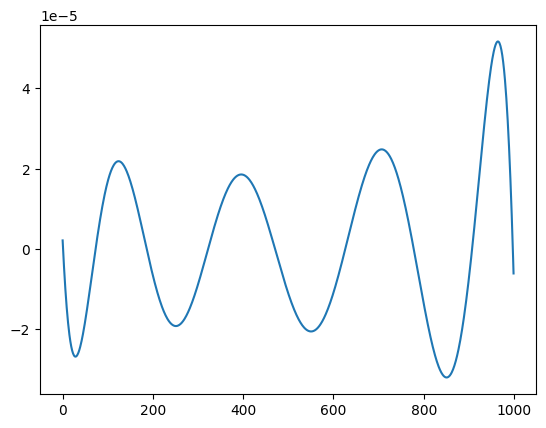

In [10]:
import matplotlib.pyplot as plt
plt.plot(u(x0) - uej)

The solution is now converged for $u^{0}_{\theta}$ and the last step `trainer.step` prepares the weights for the next time step. The trainer keeps track of the weights (the flax `State`) for each time step.

We now proceed to compute $u^{1}_{\theta}$ using $\mathcal{L}_{IC2}$ and the same trainer. All we need to do is to recompute the target of the second problem given to the `Loss` class. The target is now given by the right-hand side of the equation for $u^{1}_{\theta}$. We use the jaxfun class `Residual` to compute $c^2 \Delta t^2 \frac{\partial^2 u^{0}_{\theta}}{\partial x^2}$ 

In [11]:
from jaxfun.pinns.loss import Residual

dt = jnp.pi / 100
c = 1.0
target = Residual(c**2 * dt**2 * u.diff(x, 2), xi)
unm1 = u(xi)
loss_fn.residuals[1].target = (unm1 * (1 + c * dt) + 0.5 * target.evaluate(u.module))
trainer.train(
    opt_lbfgs, 5000, epoch_print=1000, abs_limit_loss=1e-10, print_final_loss=True
)
un = u(xi)
trainer.step(u.module)

Running optimizer LBFGS(memory_size=10)
Final loss for LBFGS(memory_size=10): 9.976032925756903e-11 after 687 epochs


We now have the solution for $u^0_{\theta}$ and $u^1_{\theta}$, and in python we store the evaluation of these solutions at the collocation points `xi` in `unm1` and `un`, respectively. Throughout `unm1` corresponds to $u^{n-1}_{\theta}(\boldsymbol{x})$ and `un` corresponds to $u^{n}_{\theta}(\boldsymbol{x})$, where $\boldsymbol{x}=(x_i)_{i=0}^{M-3}$.

All that remains is to loop over the remaining time steps and solve for $u^{n+1}_{\theta}$ using the discretized wave equation residual loss $\mathcal{L}_{PDE}^n$ and the boundary condition loss $\mathcal{L}_{BC}^n$. We implement the PDE loss by modifying the second argument of the `Loss` class, which computes the residual $u^{n+1}_{\theta}(x) - f(x)$, where $f(x)$ is a target. In the discrete PDE $f(x) = 2 u^n_{\theta} - u^{n-1}_{\theta} + c^2 \Delta t^2 \frac{\partial^2 u^{n}_{\theta}}{\partial x^2}$. This term is evaluated once from known solutions and placed in the target of the loss function.

In [12]:
import optax

from jaxfun.utils import lambdify

Nsteps = 40
for step in range(1, Nsteps):
    print(f"Time step {step + 1}/{Nsteps}")
    loss_fn.residuals[1].target = (2 * un - unm1 + target.evaluate(u.module))
    # Clear the L-BFGS optimizer state
    opt_lbfgs.opt_state = optax.tree.zeros_like(opt_lbfgs.opt_state)
    trainer.train(
        opt_lbfgs,
        2000,
        epoch_print=500,
        abs_limit_loss=1e-10,
        print_final_loss=True,
    )
    unm1 = un
    un = u(xi)
    trainer.step(u.module)

# Use exact solution to compute error
ue = sp.sin(x) * (sp.sin(c * t) + sp.cos(c * t))
x0 = mesh.get_points(1000, domain="all", kind="uniform")
uej = lambdify(x, ue.subs(t, dt * Nsteps))(x0[:, 0])

print(
    "Error at final time step:",
    jnp.linalg.norm(u(x0) - uej) / jnp.sqrt(uej.shape[0]),
)

Time step 2/40
Running optimizer LBFGS(memory_size=10)
Final loss for LBFGS(memory_size=10): 9.982538470861416e-11 after 360 epochs
Time step 3/40
Running optimizer LBFGS(memory_size=10)
Final loss for LBFGS(memory_size=10): 9.903108869899015e-11 after 73 epochs
Time step 4/40
Running optimizer LBFGS(memory_size=10)
Final loss for LBFGS(memory_size=10): 8.682567386408688e-11 after 95 epochs
Time step 5/40
Running optimizer LBFGS(memory_size=10)
Final loss for LBFGS(memory_size=10): 7.524985093563314e-11 after 77 epochs
Time step 6/40
Running optimizer LBFGS(memory_size=10)
Final loss for LBFGS(memory_size=10): 9.697636878140039e-11 after 70 epochs
Time step 7/40
Running optimizer LBFGS(memory_size=10)
Final loss for LBFGS(memory_size=10): 2.3679991724360147e-11 after 80 epochs
Time step 8/40
Running optimizer LBFGS(memory_size=10)
Final loss for LBFGS(memory_size=10): 6.27121237993143e-11 after 67 epochs
Time step 9/40
Running optimizer LBFGS(memory_size=10)
Final loss for LBFGS(memory

Notice that each time step takes just a few iterations to converge since we start with a very good initial guess from the previous time step. We can now visualize the final solution by evaluating the neural networks at chosen time steps on a grid of points in space and time. We can then plot the solution as a surface plot.

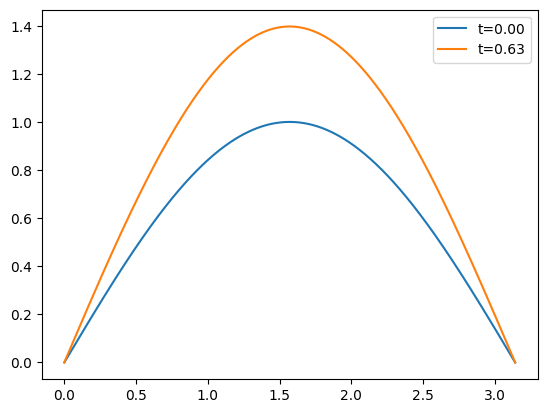

In [13]:
import matplotlib.pyplot as plt

results = []
exact = []
for step in range(Nsteps):
    results.append(trainer.evaluate_at_step(u, x0, step)[:, 0])
    exact.append(lambdify(x, ue.subs(t, step * dt))(x0[:, 0]))
    if step % 20 == 0:
        plt.plot(x0, results[-1], label=f"t={step*dt:.2f}")
plt.legend(loc="upper right")
plt.show()

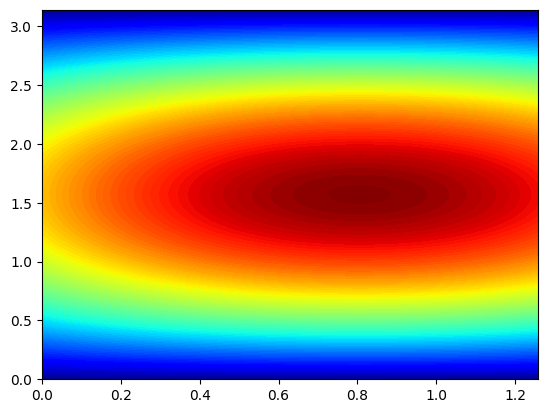

In [14]:
uj = jnp.array(results)
plt.contourf(uj.T, extent=[0, Nsteps * dt, 0, jnp.pi], levels=100, cmap="jet")

A heat map of the error between the PINN solution and the exact solution shows that the error is small throughout the domain, indicating that the PINN has successfully learned the solution to the discrete time wave equation and the error is well controlled. The time axis is along the vertical direction in the plots.

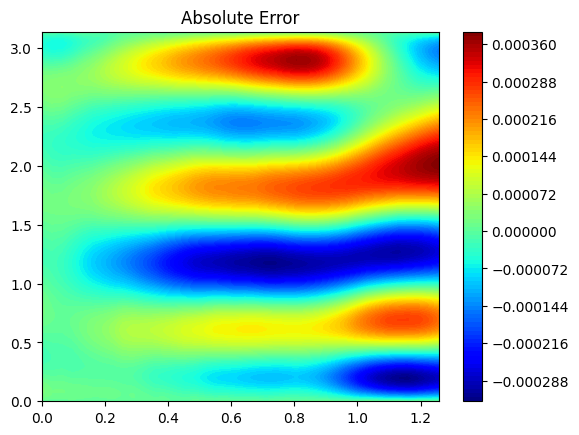

In [15]:
uej = jnp.array(exact)
plt.contourf((uej - uj).T, extent=[0, Nsteps * dt, 0, jnp.pi], levels=100, cmap="jet")
plt.title("Absolute Error")
plt.colorbar();

In [16]:
opt_lbfgs.opt_state[0]

ScaleByLBFGSState(count=OptArray( # 1 (4 B)
  value=Array(71, dtype=int32)
), params=State({
  'linear_in': {
    'bias': OptVariable( # 64 (512 B)
      value=Array([-0.95936364, -0.96052565,  0.68865315,  1.39511617, -0.10593319,
             -0.27508402,  1.27442829,  1.10270388,  0.62355897, -0.89287501,
             -0.16441558,  0.87662463,  1.06626617,  0.44160283,  0.40943059,
             -0.11559176, -0.87452576, -0.50768718,  0.20808409, -0.27806646,
             -0.54657332, -1.04245028, -0.55159128, -0.05810634, -0.32772806,
             -0.59173002, -0.50071579, -0.53031394, -0.78514662, -0.50186691,
             -0.42386592, -0.55502932, -0.15140515,  0.72865043, -1.14989641,
             -0.63793555, -0.3935349 , -0.77620877, -0.56830341,  0.06833873,
              1.82287791,  1.29491968, -0.09301894,  1.16044192,  0.02748374,
             -0.45390922, -0.26964857, -0.90660177,  1.26690785,  1.31439256,
              0.0761484 ,  1.97797809, -1.30490328, -0.26370511, -